# Задание

Используя базу «Пассажиры автобуса», подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- **входящий пассажир**
- **выходящий пассажир**

Добейтесь точности работы модели на проверочной выборке не ниже **85%**.

Ссылка на датасет: https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip


# Загрузка и распаковка датасета


In [1]:
# Скачивание архива с датасетом
!wget -q https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip -O bus.zip

# Распаковка
!unzip -q -o bus.zip -d bus_data

# Смотрим, что внутри
!ls bus_data


Входящий  Выходящий


In [2]:
# Печатаем структуру папок — разберёмся с классами и количеством файлов
import os

DATA_DIR = 'bus_data'

# Ищем папку, в которой лежат классы (может быть bus_data/bus или bus_data/ сразу)
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/  ({len(files)} файлов)')
    if level >= 2:
        dirs[:] = []  # не углубляемся слишком сильно


bus_data/  (0 файлов)
  Входящий/  (6485 файлов)
  Выходящий/  (2596 файлов)


# Импорт библиотек


In [3]:
# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import utils

# Работа с изображениями
from PIL import Image

# Массивы и графики
import numpy as np
import matplotlib.pyplot as plt
import os

# Разделение данных
from sklearn.model_selection import train_test_split

%matplotlib inline

# Фиксируем seed
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)


# Загрузка изображений в numpy-массивы

Проходим по папкам классов, читаем каждое изображение, приводим к единому размеру и складываем в массив.

**Важно:** путь `BASE_DIR` может потребоваться скорректировать после вывода структуры выше. Если картинки лежат прямо в `bus_data/входящий` и `bus_data/выходящий`, оставляем как есть. Если в `bus_data/bus/...` — меняем на `'bus_data/bus'`.


In [4]:
# Путь к папке с классами — скорректируй при необходимости
BASE_DIR = 'bus_data'

# Если после распаковки появилась вложенная папка (например, bus_data/bus),
# автоматически заходим в неё
subdirs = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
if len(subdirs) == 1 and not any(os.listdir(os.path.join(BASE_DIR, subdirs[0], d))
                                 for d in os.listdir(os.path.join(BASE_DIR, subdirs[0]))
                                 if os.path.isdir(os.path.join(BASE_DIR, subdirs[0], d))):
    pass
else:
    # Ищем, где лежат подпапки с картинками
    for d in subdirs:
        inner = os.path.join(BASE_DIR, d)
        if any(os.path.isdir(os.path.join(inner, x)) for x in os.listdir(inner)):
            BASE_DIR = inner
            break

print('Работаем с папкой:', BASE_DIR)

# Список классов (имена подпапок)
CLASSES = sorted([d for d in os.listdir(BASE_DIR)
                  if os.path.isdir(os.path.join(BASE_DIR, d))])
print('Найденные классы:', CLASSES)


Работаем с папкой: bus_data
Найденные классы: ['Входящий', 'Выходящий']


In [5]:
# Параметры предобработки изображений
IMG_SIZE = 64   # размер, к которому приводим все картинки (64x64)

def load_images(base_dir, classes, img_size):
    """Проходит по папкам классов, загружает картинки в массивы."""
    X, y = [], []
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(base_dir, class_name)
        files = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f'  Класс {class_idx} ({class_name}): {len(files)} изображений')

        for fname in files:
            path = os.path.join(class_dir, fname)
            try:
                img = Image.open(path).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img))
                y.append(class_idx)
            except Exception as e:
                print(f'    пропущено {fname}: {e}')

    return np.array(X), np.array(y)

print('Загружаем изображения...')
X, y = load_images(BASE_DIR, CLASSES, IMG_SIZE)
print(f'\nИтого:')
print(f'  X: {X.shape}  (изображения)')
print(f'  y: {y.shape}  (метки классов)')
print(f'  Баланс классов: {np.bincount(y)}')


Загружаем изображения...
  Класс 0 (Входящий): 6485 изображений
  Класс 1 (Выходящий): 2596 изображений

Итого:
  X: (9081, 64, 64, 3)  (изображения)
  y: (9081,)  (метки классов)
  Баланс классов: [6485 2596]


## Визуализация примеров


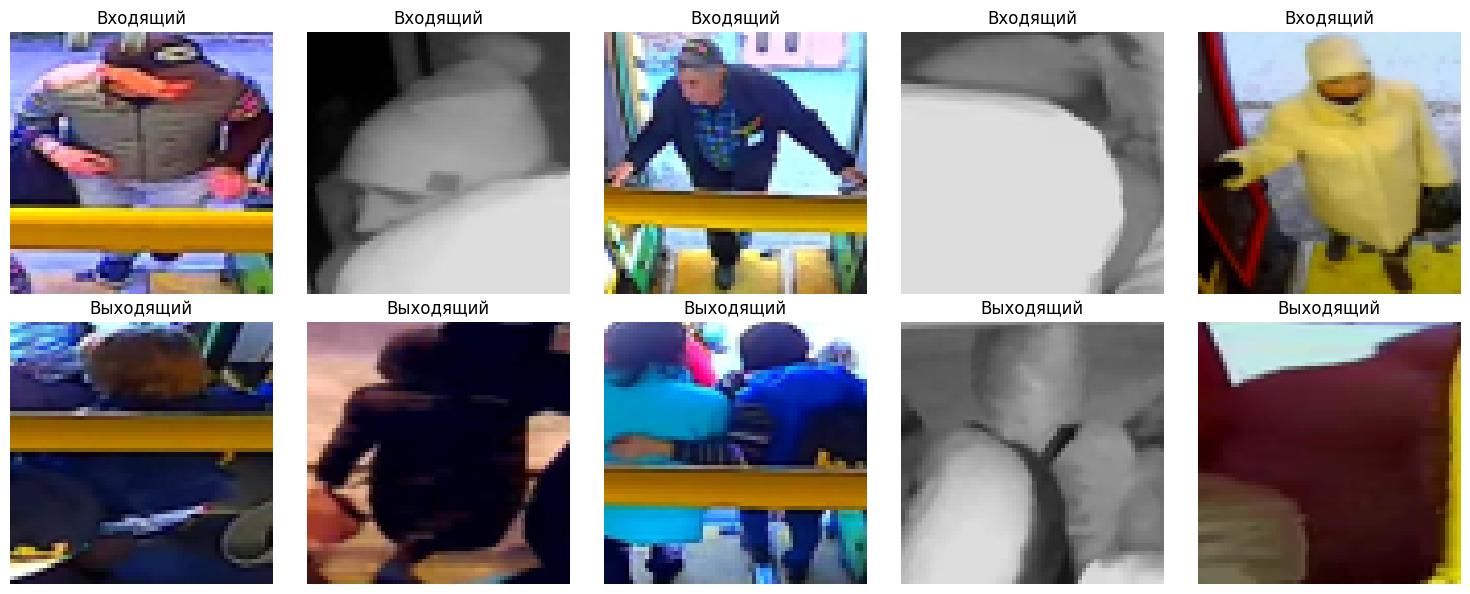

In [6]:
# По несколько примеров каждого класса
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for class_idx, class_name in enumerate(CLASSES):
    class_imgs = X[y == class_idx][:5]
    for i, img in enumerate(class_imgs):
        axes[class_idx, i].imshow(img)
        axes[class_idx, i].set_title(f'{class_name}')
        axes[class_idx, i].axis('off')
plt.tight_layout()
plt.show()


# Подготовка данных

- Нормализация в диапазон [0, 1]
- One-hot encoding меток (2 класса)
- Разделение на обучающую и проверочную выборки


In [7]:
# Нормализация
X = X.astype('float32') / 255.

# One-hot encoding (2 класса)
y_cat = utils.to_categorical(y, 2)

# Разделение на train / validation (80% / 20%)
x_train, x_val, y_train, y_val = train_test_split(
    X, y_cat,
    test_size=0.2,
    shuffle=True,
    stratify=y,         # сохраняем баланс классов
    random_state=42
)

print(f'Обучающая выборка:   {x_train.shape}, {y_train.shape}')
print(f'Проверочная выборка: {x_val.shape},   {y_val.shape}')


Обучающая выборка:   (7264, 64, 64, 3), (7264, 2)
Проверочная выборка: (1817, 64, 64, 3),   (1817, 2)


# Построение модели

Для классификации изображений используем **свёрточную нейронную сеть (CNN)** — она работает с картинками намного лучше, чем полносвязная.

Архитектура:
- 2 блока «Conv2D → BatchNorm → MaxPool» для извлечения признаков
- Flatten + Dense для классификации
- Dropout для борьбы с переобучением


In [8]:
def build_model():
    model = Sequential()

    # Первый свёрточный блок
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Второй свёрточный блок
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Третий свёрточный блок
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Классификатор
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,106 (4.36 MB)

 Trainable params: 1,142,658 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

# Обучение модели

Используем `EarlyStopping`, который следит за `val_accuracy` и останавливает обучение, если точность перестала расти.


In [9]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8063 - loss: 0.5524 - val_accuracy: 0.6852 - val_loss: 0.7204
Epoch 2/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8874 - loss: 0.2466 - val_accuracy: 0.9108 - val_loss: 0.2398
Epoch 3/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9182 - loss: 0.1859 - val_accuracy: 0.9103 - val_loss: 0.2054
Epoch 4/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9401 - loss: 0.1328 - val_accuracy: 0.9406 - val_loss: 0.1276
Epoch 5/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9442 - loss: 0.1227 - val_accuracy: 0.9538 - val_loss: 0.1086
Epoch 6/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9537 - loss: 0.1128 - val_accuracy: 0.9560 - val_loss: 0.1133
Epoch 7/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9689 - loss: 0.0805 - val_accuracy: 0.9483 - val_loss: 0.1381
Epoch 8/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9693 - loss: 0.0771 - val_accuracy: 

# Результаты


In [10]:
# Точность на проверочной выборке
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
print(f'Точность на проверочной выборке: {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'Порог 85% {"пройден ✅" if val_acc >= 0.85 else "НЕ пройден ❌"}')

# Лучшая точность за всё обучение (restore_best_weights уже применён)
best_val_acc = max(history.history['val_accuracy'])
print(f'Максимальная val_accuracy за обучение: {best_val_acc:.4f}')


Точность на проверочной выборке: 0.9901 (99.01%)
Порог 85% пройден ✅
Максимальная val_accuracy за обучение: 0.9901


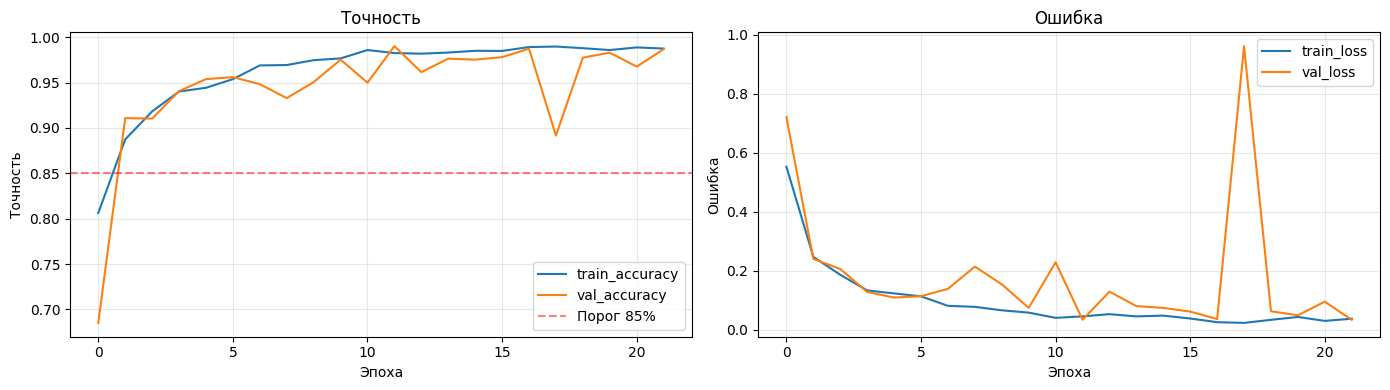

In [11]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='train_accuracy')
axes[0].plot(history.history['val_accuracy'], label='val_accuracy')
axes[0].axhline(0.85, color='red', linestyle='--', alpha=0.5, label='Порог 85%')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Точность')
axes[0].set_title('Точность')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Ошибка')
axes[1].set_title('Ошибка')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---

## Если 85% не достигнуто — аугментация данных

Если с первого раза точность не дотянула до 85%, запусти эту ячейку — она обучит модель с аугментацией (случайные повороты, отражения, сдвиги), что заметно улучшает результат на небольших датасетах. Согласно теории, аугментация — это «дополнение малопредставленных классов» и искусственное расширение базы.


In [12]:
# ImageDataGenerator с аугментацией
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)

# Новая модель (чтобы обучать с нуля)
model_aug = build_model()

early_stop_aug = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=15,
    restore_best_weights=True
)

history_aug = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_val, y_val),
    epochs=80,
    callbacks=[early_stop_aug],
    verbose=1
)

val_loss, val_acc = model_aug.evaluate(x_val, y_val, verbose=0)
print(f'\nТочность с аугментацией: {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'Порог 85% {"пройден ✅" if val_acc >= 0.85 else "НЕ пройден ❌"}')


Epoch 1/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.7514 - loss: 0.6393 - val_accuracy: 0.4051 - val_loss: 2.0278
Epoch 2/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8055 - loss: 0.4225 - val_accuracy: 0.8068 - val_loss: 0.4200
Epoch 3/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8272 - loss: 0.3763 - val_accuracy: 0.8668 - val_loss: 0.2957
Epoch 4/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8393 - loss: 0.3568 - val_accuracy: 0.8305 - val_loss: 0.3734
Epoch 5/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8535 - loss: 0.3255 - val_accuracy: 0.8817 - val_loss: 0.2567
Epoch 6/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8644 - loss: 0.3080 - val_accuracy: 0.8789 - val_loss: 0.2502
Epoch 7/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8721 - loss: 0.2814 - val_accuracy: 0.8899 - val_loss: 0.2328
Epoch 8/80
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8733 - loss: 0.2764 - v